## Experiment No: 9
## Experiment Title: Density-Based Clustering using DBSCAN - Identifying Cluster Structure and Noise Points

**Name:** Himanshu Jadhav  
**Roll Number:** TE-32

### Step 1: Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
np.random.seed(33)

print("Libraries Imported Successfully")

Libraries Imported Successfully


### Loading the Dataset

In [2]:
df = pd.read_csv("wildlife_gps_tracking.csv")

print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)
df.head()

Dataset Loaded Successfully
Dataset Shape: (790, 7)


,elephant_id,day_of_season,hour_of_day,longitude_km,latitude_km,ambient_temp_c,true_region
0,EL-620,74,5,23.940,30.079,30.7,Migration Corridor
1,EL-342,29,18,44.314,12.001,32.8,Home Range
2,EL-656,83,0,24.634,7.821,30.9,Feeding Ground
3,EL-700,12,13,19.224,29.798,30.7,Migration Corridor
4,EL-186,58,13,8.617,39.749,24.2,Main Waterhole


### Step 3: Visualize the Raw GPS Ping Locations

<Figure size 800x700 with 0 Axes>

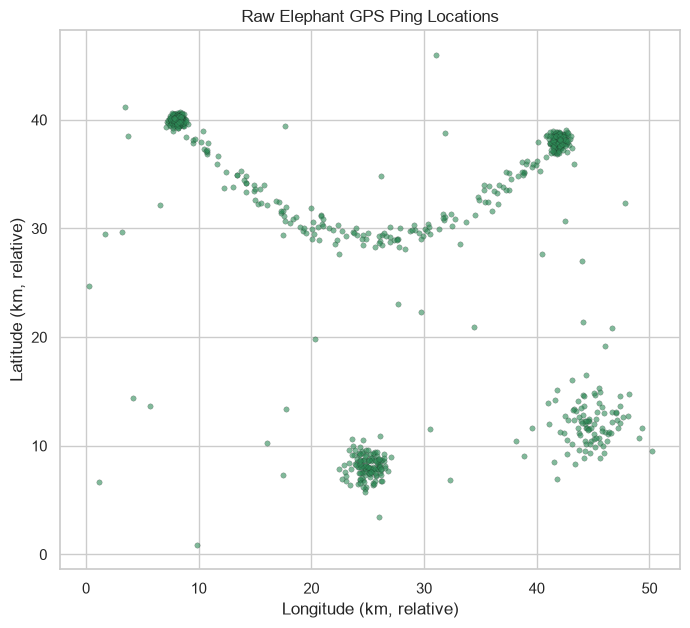

In [3]:
plt.figure(figsize=(8, 7))
plt.figure(figsize=(8, 7))
plt.scatter(df["longitude_km"], df["latitude_km"], s=15, alpha=0.6, edgecolor="k", linewidth=0.2, color="seagreen")
plt.xlabel("Longitude (km, relative)")
plt.ylabel("Latitude (km, relative)")
plt.title("Raw Elephant GPS Ping Locations")
plt.show()

### Step 4: Feature Scaling

In [4]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[["longitude_km", "latitude_km"]])

print("Features scaled successfully. Mean:", X_scaled.mean(axis=0), "Std Dev:", X_scaled.std(axis=0))

Features scaled successfully. Mean: [ 1.12427648e-16 -5.28409946e-17] Std Dev: [1. 1.]


### Step 5: Find a Suitable 'eps' Value using K-Distance Graph


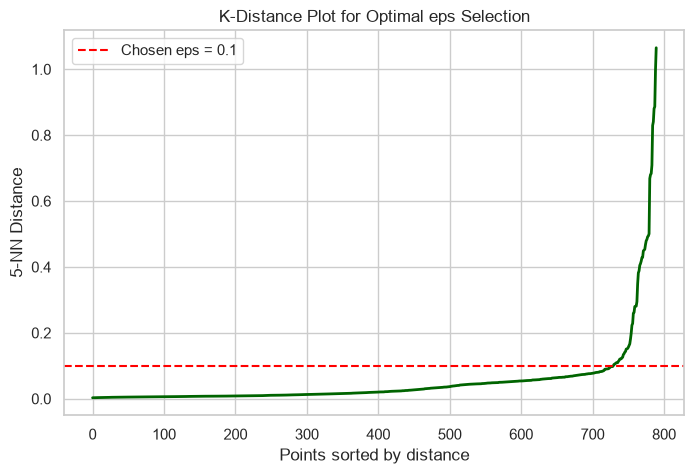

In [5]:
k  = 5
nn = NearestNeighbors(n_neighbors=k).fit(X_scaled)

distances, _     = nn.kneighbors(X_scaled)
sorted_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(8, 5))
plt.plot(sorted_distances, color="darkgreen", linewidth=2)
plt.axhline(y=0.1, color="red", linestyle="--", label="Chosen eps = 0.1")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k}-NN Distance")
plt.title("K-Distance Plot for Optimal eps Selection")
plt.legend()
plt.show()

### Step 6: Apply DBSCAN on the Wildlife GPS Dataset

In [6]:
dbscan         = DBSCAN(eps=0.1, min_samples=5)
cluster_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise    = list(cluster_labels).count(-1)

print(f"DBSCAN found {n_clusters} clusters and identified {n_noise} noise points.")


DBSCAN found 5 clusters and identified 47 noise points.


### Step 7: Visualize DBSCAN Clustering Result

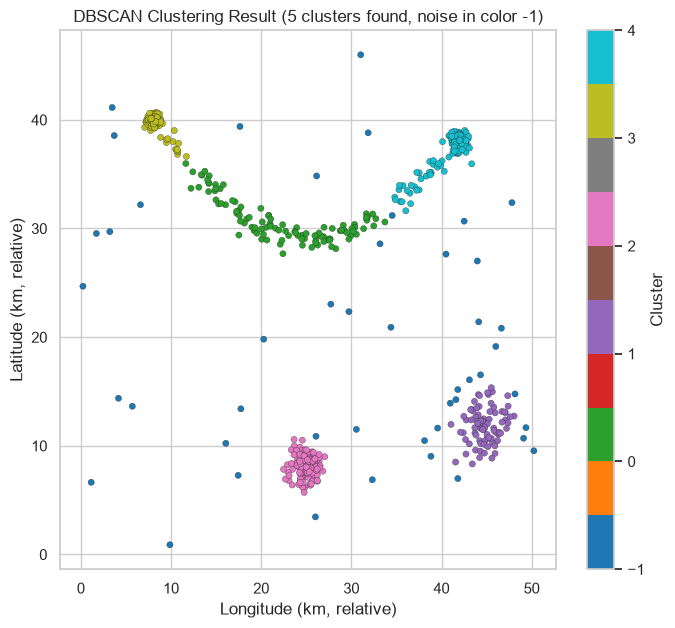

Adjusted Rand Index vs true regions: 0.8185


In [7]:
plt.figure(figsize=(8, 7))
scatter = plt.scatter(df["longitude_km"], df["latitude_km"], c=cluster_labels, cmap="tab10", s=20, edgecolor="k", linewidth=0.2)
plt.xlabel("Longitude (km, relative)")
plt.ylabel("Latitude (km, relative)")
plt.title(f"DBSCAN Clustering Result ({n_clusters} clusters found, noise in color -1)")
plt.colorbar(scatter, label="Cluster")
plt.show()

ari = adjusted_rand_score(df["true_region"], cluster_labels)
print(f"Adjusted Rand Index vs true regions: {ari:.4f}")

### Step 8: Demonstrate DBSCAN's Strength on Non-Globular Data (Moons Dataset)

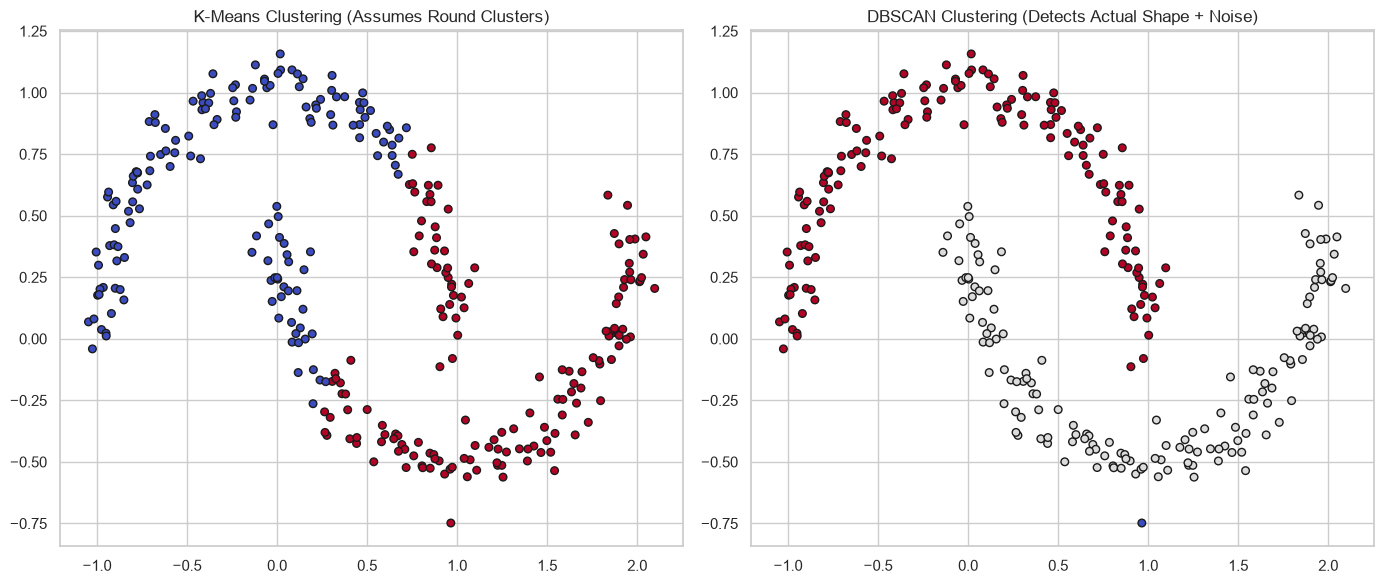

DBSCAN found 2 clusters
Noise points detected by DBSCAN: 1

Observation: K-Means splits the moon shapes incorrectly since it assumes round clusters.
DBSCAN correctly follows the curved density structure, just as it did with the migration corridor above.


In [8]:
from sklearn.datasets import make_moons

X_moons, _ = make_moons(n_samples=300, noise=0.07, random_state=33)

dbscan_moons = DBSCAN(eps=0.2, min_samples=5)
moons_labels_dbscan = dbscan_moons.fit_predict(X_moons)

kmeans_moons = KMeans(n_clusters=2, n_init=10, random_state=33)
moons_labels_kmeans = kmeans_moons.fit_predict(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=moons_labels_kmeans, cmap="coolwarm", s=30, edgecolor="k")
axes[0].set_title("K-Means Clustering (Assumes Round Clusters)")

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=moons_labels_dbscan, cmap="coolwarm", s=30, edgecolor="k")
axes[1].set_title("DBSCAN Clustering (Detects Actual Shape + Noise)")

plt.tight_layout()
plt.show()

n_noise_moons = list(moons_labels_dbscan).count(-1)
print(f"DBSCAN found {len(set(moons_labels_dbscan)) - (1 if -1 in moons_labels_dbscan else 0)} clusters")
print(f"Noise points detected by DBSCAN: {n_noise_moons}")
print("\nObservation: K-Means splits the moon shapes incorrectly since it assumes round clusters.")
print("DBSCAN correctly follows the curved density structure, just as it did with the migration corridor above.")

### Step 9: Evaluate Clustering Quality using Silhouette Score

In [9]:
mask = cluster_labels != -1
if len(set(cluster_labels[mask])) > 1:
    sil_score = silhouette_score(X_scaled[mask], cluster_labels[mask])
    print(f"Silhouette Score (Wildlife GPS Dataset, excluding noise): {sil_score:.4f}")
else:
    print("Not enough clusters (excluding noise) to compute silhouette score.")

Silhouette Score (Wildlife GPS Dataset, excluding noise): 0.8359


### Step 10: Final Output

In [10]:
print("Experiment Completed Successfully")
print(f"\nWildlife GPS Dataset -> Clusters found: {n_clusters}, Noise points: {n_noise}, ARI vs ground truth: {ari:.4f}")
print(f"Moons Dataset        -> Clusters found: {len(set(moons_labels_dbscan)) - (1 if -1 in moons_labels_dbscan else 0)}, Noise points: {n_noise_moons}")

Experiment Completed Successfully

Wildlife GPS Dataset -> Clusters found: 5, Noise points: 47, ARI vs ground truth: 0.8185
Moons Dataset        -> Clusters found: 2, Noise points: 1
